In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
SEED = 42


In [4]:
df = pd.read_csv("Churn_Modelling.csv")
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

print(df["Exited"].value_counts())
churn_rate = df["Exited"].mean() * 100
print(f"churn rate: {churn_rate:.2f}%")

Exited
0    7963
1    2037
Name: count, dtype: int64
churn rate: 20.37%


Text(0.5, 1.0, 'stayed (0) vs churned (1)')

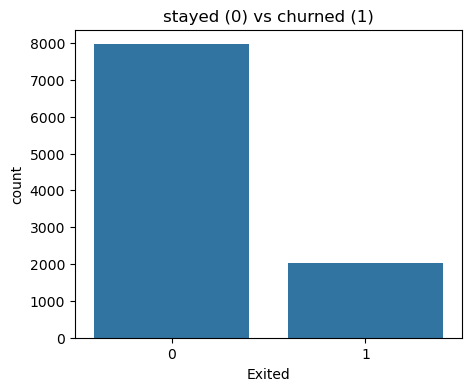

In [7]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="Exited", data=df)
plt.title("stayed (0) vs churned (1)")

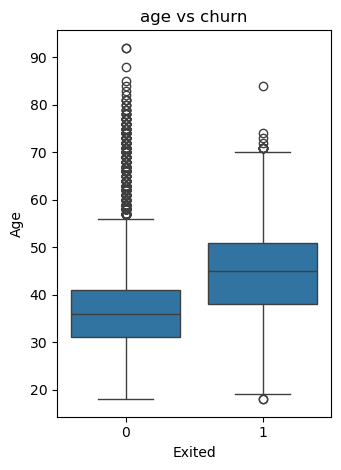

In [8]:
plt.subplot(1, 2, 2)
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("age vs churn")
plt.tight_layout()
plt.savefig("eda_overview.png")
plt.show()

In [9]:
le_geo = LabelEncoder()
le_gender = LabelEncoder()
df["Geography"] = le_geo.fit_transform(df["Geography"])
df["Gender"] = le_gender.fit_transform(df["Gender"])

X = df.drop("Exited", axis=1)
y = df["Exited"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"train size: {len(X_train)}, test size: {len(X_test)}")

train size: 8000, test size: 2000


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=SEED),
}

for name, model in models.items():
    print(f"training {name}...")
    model.fit(X_train, y_train)
print("done training")


training Logistic Regression...
training Random Forest...
training Gradient Boosting...
done training


Logistic Regression
              precision    recall  f1-score   support

      stayed       0.91      0.70      0.79      1593
     churned       0.38      0.72      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000

confusion matrix:
[[1123  470]
 [ 115  292]]
roc auc score: 0.7741

Random Forest
              precision    recall  f1-score   support

      stayed       0.91      0.89      0.90      1593
     churned       0.60      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000

confusion matrix:
[[1415  178]
 [ 138  269]]
roc auc score: 0.8546

Gradient Boosting
              precision    recall  f1-score   support

      stayed       0.88      0.96      0.92      1593
     churned       0.77      0.49      0.60      

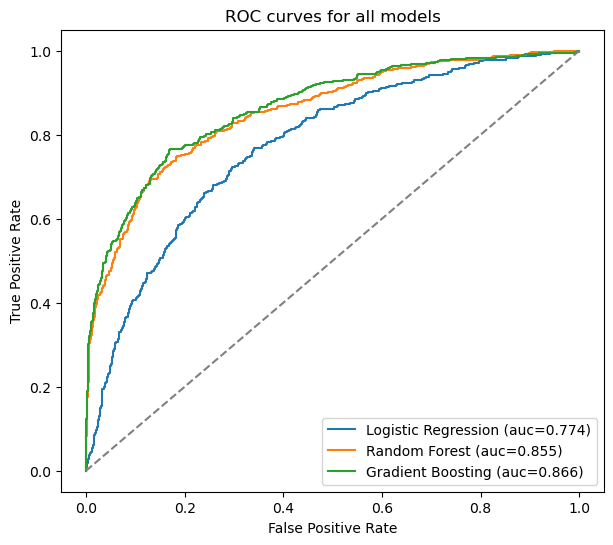

In [11]:
plt.figure(figsize=(7, 6))

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(name)
    print(classification_report(y_test, preds, target_names=["stayed", "churned"]))
    print("confusion matrix:")
    print(confusion_matrix(y_test, preds))

    auc = roc_auc_score(y_test, probs)
    print(f"roc auc score: {auc:.4f}\n")

    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (auc={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves for all models")
plt.legend()
plt.savefig("model_evaluation.png")
plt.show()

Age                0.318160
NumOfProducts      0.211426
Balance            0.116050
EstimatedSalary    0.090305
CreditScore        0.085598
IsActiveMember     0.053572
Tenure             0.047990
Geography          0.043157
Gender             0.021839
HasCrCard          0.011903
dtype: float64


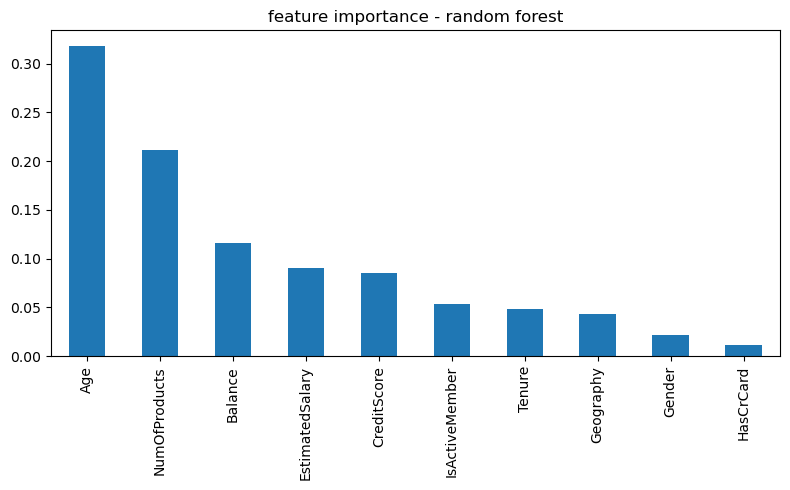

In [12]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("feature importance - random forest")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
